### Entraînement et comparaison CNN sur CIFAR-10 (Seam Carving vs MaxPooling)

Ce notebook compare deux architectures CNN simples sur le dataset **CIFAR-10** :
- **CNNWithSeamCarving** : qui utilise le Seam Carving comme méthode de pooling,
- **CNNWithMaxPooling** : qui utilise le MaxPooling standard de PyTorch.

Fonctionnalités :
- Prétraitement de CIFAR-10 avec sous-échantillonnage possible,
- Entraînement rapide sur un sous-ensemble réduit (ex. 500 images),
- Évaluation sur 2 classes CIFAR
- Comparaison des performances (loss, précision, classification report),
- Affichage des courbes de perte.

Ce notebook permet de tester l'intégration du Seam Carving comme alternative au MaxPooling dans des CNNs standards.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import Subset
from torchvision.datasets import CIFAR10
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from seam_carving_for_CNN import SeamCarvingPooling,CNNWithSeamCarving,CNNWithMaxPooling # Importing the seam carving function
import numpy as np
from pathlib import Path
import os
import pandas as pd
from PIL import Image
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# chargement rapide du dataset

# Chargement rapide de CIFAR-10 (500 images d'entraînement et 200 de test)
#transform = transforms.ToTensor()
#full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
#subset_trainset = Subset(full_trainset, range(500))
#trainloader = DataLoader(subset_trainset, batch_size=1, shuffle=True)

#testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
#subset_testset = Subset(testset, range(200))
#testloader = DataLoader(subset_testset, batch_size=1, shuffle=False)

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#criterion = nn.CrossEntropyLoss()

# Chargement du CIFAR-10 filtré (2 classes : avion = 0, voiture = 1)
transform = transforms.ToTensor()
full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
full_testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# On sélectionne uniquement les indices des classes 0 et 1 (avion et voiture)
classes_to_keep = [0, 1]

train_indices = [i for i, (_, label) in enumerate(full_trainset) if label in classes_to_keep]
test_indices = [i for i, (_, label) in enumerate(full_testset) if label in classes_to_keep]

# On crée des sous-ensembles de 500 images max (250/250) pour un entraînement rapide
train_subset = torch.utils.data.Subset(full_trainset, train_indices[:500])
test_subset = torch.utils.data.Subset(full_testset, test_indices[:200])


# On définit les data loaders
trainloader = DataLoader(train_subset, batch_size=1, shuffle=True)
testloader = DataLoader(test_subset, batch_size=1, shuffle=False)

classes = ["airplane", "automobile"]

In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def train_and_evaluate(model, name, trainloader, testloader, criterion, epochs=10):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    losses = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            outputs = outputs.view(inputs.size(0), -1)[:, :2]  # 2 classes
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        avg_loss = running_loss / len(trainloader)
        losses.append(avg_loss)
        print(f"[{name}] Époque {epoch+1} - Perte : {avg_loss:.4f}")

    # Évaluation
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            outputs = outputs.view(inputs.size(0), -1)[:, :2]
            _, predicted = torch.max(outputs, 1)
            all_preds.append(predicted.item())
            all_labels.append(labels.item())

    print(f"\n Rapport de classification pour {name} :\n")
    print(classification_report(all_labels, all_preds, target_names=classes))

    return losses


In [ ]:
# Code pour charger les modèles sauvegardés (évite de réentrainer, la cellule suivnate peut être ignorés)
from seam_carving_for_CNN import CNNWithSeamCarving
from seam_carving_for_CNN import CNNWithMaxPooling

# Instancier un modèle vide
model_seam = CNNWithSeamCarving()
model_maxp = CNNWithMaxPooling()

# Charger les poids sauvegardés
model_seam.load_state_dict(torch.load("models/cnn_seamcarving.pth"))
model_maxp.load_state_dict(torch.load("models/cnn_maxpooling.pth"))

# Passer en mode évaluation
model_seam.eval()
model_maxp.eval()

In [ ]:
# Instanciation of the CNN models with seam carving and max pooling

criterion = nn.CrossEntropyLoss()

model_seam = CNNWithSeamCarving()
model_maxp = CNNWithMaxPooling()

# Entraînement des deux
losses_seam = train_and_evaluate(model_seam, "SeamCarving", trainloader, testloader, criterion, epochs=10)
losses_maxp = train_and_evaluate(model_maxp, "MaxPooling", trainloader, testloader, criterion, epochs=10)


[SeamCarving] Époque 1 - Perte : 0.5630
[SeamCarving] Époque 2 - Perte : 0.4017
[SeamCarving] Époque 3 - Perte : 0.2823
[SeamCarving] Époque 4 - Perte : 0.1953
[SeamCarving] Époque 5 - Perte : 0.1437
[SeamCarving] Époque 6 - Perte : 0.1224
[SeamCarving] Époque 7 - Perte : 0.0851
[SeamCarving] Époque 8 - Perte : 0.0671
[SeamCarving] Époque 9 - Perte : 0.0399
[SeamCarving] Époque 10 - Perte : 0.0810

 Rapport de classification pour SeamCarving :

              precision    recall  f1-score   support

    airplane       0.82      0.92      0.86       106
  automobile       0.89      0.77      0.82        94

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200

[MaxPooling] Époque 1 - Perte : 0.5392
[MaxPooling] Époque 2 - Perte : 0.3358
[MaxPooling] Époque 3 - Perte : 0.2508
[MaxPooling] Époque 4 - Perte : 0.2106
[MaxPooling] Époque 5 - Perte : 0.1754
[MaxPooling] Époque 6 - Perte

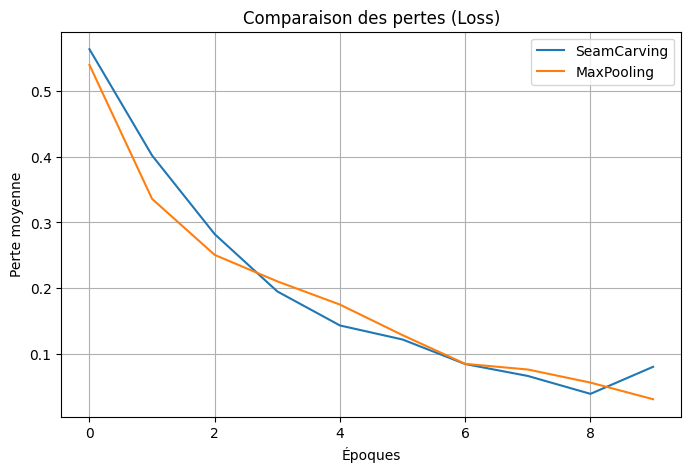

              precision    recall  f1-score   support

    airplane       0.82      0.92      0.86       106
  automobile       0.89      0.77      0.82        94

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200



In [ ]:
# métriques fines

# Tracer les pertes
plt.figure(figsize=(8, 5))
plt.plot(losses_seam, label="SeamCarving")
plt.plot(losses_maxp, label="MaxPooling")
plt.title("Comparaison des pertes (Loss)")
plt.xlabel("Époques")
plt.ylabel("Perte moyenne")
plt.grid(True)
plt.legend()
plt.show()

# Métriques fines (précision, recall, f1-score)
from sklearn.metrics import classification_report

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in testloader:
        inputs = inputs.to(device)
        outputs = model_seam(inputs)
        outputs = outputs.view(1, -1)[:, :10]
        _, predicted = torch.max(outputs, 1)
        all_preds.append(predicted.item())
        all_labels.append(labels.item())

print(classification_report(all_labels, all_preds, target_names=classes))


### On note ici que l'utilisation du seam carving à la place du max pooling n'apporte pas de bénéfice sur la précision des résultats 

MaxPooling est un peu plus performant dans ce cas précis, alors que le Seam Carving converge bien, mais reste légèrement en retrait, la perte finale est plus basse pour Seam Carving, mais cela n’induit pas de meilleure précision.


| Métrique           | SeamCarving | MaxPooling                      |
| ------------------ | ----------- | ------------------------------- |
| Accuracy           | **0.84**    | **0.89**                        |
| F1-score (moyenne) | 0.84        | 0.89                            |
| Perte finale       | 0.0810      | environ 0.25 (pas tout affiché) |

Hypothèses probables :

    - Le dataset CIFAR-10 est très structuré (centré, bien contrasté), donc MaxPooling ne détruit pas autant d’information que sur des images naturelles ou complexes.

    - Le modèle est encore assez simple (2 convolutions seulement).

Dans l’article original, Seam Carving apporte un gain parce que :
    
    - Les objets sont petits, mal centrés, et sur fond complexe (oiseaux dans la nature),

    - Le redimensionnement par MaxPooling supprime des structures utiles,

    - Seam Carving, lui, préserve les bords et contours saillants.

### Une tentative d'implémentation avec le dataset de l'article a été tenté mais n'as pas aboutie à des résultats convianquants par manque de temps (cf notebook eval_seam_carving_cub200)

In [ ]:
# Création du dossier de sauvegarde s'il n'existe pas
import os
os.makedirs("models", exist_ok=True)

# Sauvegarde des poids des deux modèles
torch.save(model_seam.state_dict(), "models/cnn_seamcarving.pth")
torch.save(model_maxp.state_dict(), "models/cnn_maxpooling.pth")

print("✅ Poids des modèles sauvegardés dans le dossier 'models/'")


✅ Poids des modèles sauvegardés dans le dossier 'models/'
